# P6: Probability and Bayes' Rule

**FIT1061 Introduction to Artificial Intelligence — Week 6**

In 2011, IBM Watson beat the best human Jeopardy! players by combining probability with language processing. Watson didn't "know" the answers — it computed **confidence scores** using probability. This notebook teaches you the mathematical foundation: conditional probability and Bayes' rule.

> **Pre-workshop prep:** Work through the *Probability Refresh* prep guide before starting. It covers conditional probability and P(A|B) notation.

> **🗣 Milestone task.** P6 requires a tutor discussion for sign-off. After completing all parts (including the personalised hand-computation and the reflection), submit to OnTrack and book a discussion with your tutor.

> **P6.1 is personalised by your Monash student ID** — see the 'Your personalised instance' section below.


---

## Part A: Building a spam detector from raw data

You're a data scientist building a spam filter. You have a dataset of 20 emails. Each email has a label (spam or ham) and a set of words that appear in it.

Your goal: given a **new email** containing the word "free", what is the probability it is spam?

To answer this, you'll need to **count things in the data**, then use those counts to compute probabilities. No NumPy, just plain Python.

### Quick warm-up: do you remember probability?

Before diving in, check that you're comfortable with the basics (from the prep guide):

1. What is the probability of rolling an even number on a fair die? *(Answer: 3/6 = 1/2)*
2. If 8 out of 20 emails are spam, what is P(spam)? *(Answer: 8/20 = 0.4)*
3. In words, what does P(A|B) mean? *(Answer: the probability of A, given that B has happened)*

If these feel unfamiliar, work through the **"Probability Refresh"** prep guide before continuing.

---

## Warm-up: the puzzle from the whiteboard

In the lecture we traced the **disease-test puzzle** on the board. Work through it yourself to
warm up, then hand-compute Bayes on your own scenario in Part 0.

Stuck? This is the puzzle the class voted on at the start of the lecture; revisit the slides or
the workshop.

A disease affects **1%** of people. A test is **99% accurate**: it is correct 99% of the time
on people who have the disease (sensitivity) *and* 99% of the time on people who do not
(specificity). You test positive. What is the probability you have the disease?

Build the frequency tree over **10,000 people** by hand and fill in the blanks:

| Group | How many | Test positive | Count |
|---|---|---|---|
| Have the disease (1%) | ? | 99% of them | ? (true positives) |
| Do **not** have it (99%) | ? | 1% of them | ? (false positives) |

- Total who test positive = ? + ? = ?
- **P(disease | positive)** = (true positives) / (total positives) = ? / ? = **?**

*(Same computation as Part 0 below, where you use YOUR personalised base rate, sensitivity, and
specificity.)*


---

## Your personalised instance (P6.1)

Before working through the spam classifier (Part A) and the COVID test (Part B), apply Bayes' rule **by hand** to a scenario personalised by your Monash student ID.

**Set your Monash student ID below**, then run the next two cells. Do not edit `task_instances.py`.


In [2]:
# Replace the placeholder with your Monash student ID (8 digits).
STUDENT_ID = "37524720"

assert STUDENT_ID.isdigit() and len(STUDENT_ID) == 8, (
    "Set STUDENT_ID to your 8-digit Monash student ID (digits only, in quotes)."
)


In [3]:
# Integrity check + instance generation.
# DO NOT EDIT task_instances.py — your tutor regenerates from your ID
# and compares fingerprints. Modifications will be caught.

from task_instances import generate_instance
from task_instances_lib import fingerprint

instance = generate_instance(STUDENT_ID)
scenario = instance["bayes"]

print(f"Student ID:                {STUDENT_ID}")
print(f"task_instances.py SHA-256: {fingerprint('task_instances.py')}")
print()
print(scenario.describe())


Student ID:                37524720
task_instances.py SHA-256: 9f55fe9310cb3975536b82b49809be58809c5b9000d647a108471608300e0397

Personalised Bayes scenario for student 37524720
  scenario:    automated radiology triage
  base_rate    P(condition)              = 0.0638
  sensitivity  P(positive | condition)   = 0.8809
  specificity  P(negative | no condition)= 0.9875


---

## Part 0: Hand-compute Bayes on YOUR scenario (P6.1)

**Before coding any of Part A or Part B**, compute the posterior $P(\text{condition} \mid \text{positive})$ for YOUR scenario by hand.

You have:
- $P(\text{condition}) = $ your `base_rate`
- $P(\text{positive} \mid \text{condition}) = $ your `sensitivity`
- $P(\text{negative} \mid \text{no condition}) = $ your `specificity`, so $P(\text{positive} \mid \text{no condition}) = 1 - \text{specificity}$

**Step 1: Total probability of a positive result** (law of total probability):

$$
P(\text{positive}) = P(\text{positive} \mid \text{condition})\, P(\text{condition})
                   + P(\text{positive} \mid \text{no condition})\, P(\text{no condition})
$$

**Step 2: Bayes' rule:**

$$
P(\text{condition} \mid \text{positive})
  = \frac{P(\text{positive} \mid \text{condition})\, P(\text{condition})}{P(\text{positive})}
$$

Show your working on paper (substitute YOUR numbers, intermediate steps, final value to 4 decimal places). Photograph it.

> **Different students get different scenarios.** Your posterior will differ from a peer's. Tutors regenerate from your Monash ID and compare to ±0.005 tolerance on the posterior.

> **Do not use Python for this part.** Hand-compute on paper. You'll verify with code in Parts A and B. You can use a calculator for the arithmetic. 


In [6]:
# Articulation answers — type your hand-computed values here.
# Reference YOUR scenario printed above. Show 4 decimal places.

answers = {
    "scenario_name": "automated radiology triage",            # string
    "base_rate": 0.0638,                # float, 4 dp
    "sensitivity": 0.8809,              # float, 4 dp
    "specificity":  0.9875,              # float, 4 dp
    "p_positive": 0.0679,               # float, 4 dp (from Step 1)
    "p_condition_given_positive": 0.8277,  # float, 4 dp (from Step 2 — the posterior)
}

# Brief explanation (2-3 sentences) — is the posterior smaller or larger than
# you'd expect from sensitivity alone? Why? Reference YOUR numbers:
explanation = (
"you can get the answer base on the formula above it. According to the formula, i will expected to have 3 stuff if i want to count P(condition |positive), which is P(condition), P(positive|condition) and P(positive|no condition, which are provided by the question)"
)

# Sanity checks (only verify the cell is filled, not correctness).
for k, v in answers.items():
    assert v is not None, f"answers['{k}'] is still None"
assert explanation.strip() != "TYPE YOUR EXPLANATION HERE.", "Write your explanation."
print("Filled in. Photograph hand calculation + this cell for P6.1.")


Filled in. Photograph hand calculation + this cell for P6.1.


### The dataset

Run the cell below to load the email dataset. Each email is a dictionary with a `label` ("spam" or "ham") and a list of `words`.

In [7]:
emails = [
    {"label": "spam", "words": ["free", "winner", "click"]},
    {"label": "spam", "words": ["free", "offer", "limited"]},
    {"label": "spam", "words": ["free", "prize", "winner"]},
    {"label": "spam", "words": ["click", "free", "now"]},
    {"label": "spam", "words": ["winner", "free", "congratulations"]},
    {"label": "spam", "words": ["offer", "limited", "act"]},
    {"label": "spam", "words": ["free", "discount", "offer"]},
    {"label": "spam", "words": ["click", "winner", "free"]},
    {"label": "ham",  "words": ["meeting", "tuesday", "agenda"]},
    {"label": "ham",  "words": ["meeting", "project", "update"]},
    {"label": "ham",  "words": ["lunch", "tuesday", "free"]},
    {"label": "ham",  "words": ["project", "deadline", "friday"]},
    {"label": "ham",  "words": ["meeting", "notes", "attached"]},
    {"label": "ham",  "words": ["report", "quarterly", "review"]},
    {"label": "ham",  "words": ["meeting", "cancelled", "tuesday"]},
    {"label": "ham",  "words": ["project", "update", "progress"]},
    {"label": "ham",  "words": ["team", "lunch", "friday"]},
    {"label": "ham",  "words": ["agenda", "meeting", "room"]},
    {"label": "ham",  "words": ["deadline", "extended", "monday"]},
    {"label": "ham",  "words": ["review", "feedback", "report"]},
]

print(f"Total emails: {len(emails)}")
print(f"\nFirst 3 emails:")
for e in emails[:3]:
    print(f"  [{e['label']:4s}] {e['words']}")

Total emails: 20

First 3 emails:
  [spam] ['free', 'winner', 'click']
  [spam] ['free', 'offer', 'limited']
  [spam] ['free', 'prize', 'winner']


### Step 1: Count the classes

Before computing any probabilities, you need to know how many spam and ham emails are in the dataset. Write Python code to count them.

In [12]:
spam_count = 0
ham_count = 0
# --- YOUR CODE HERE ---

# Count how many emails are spam and how many are ham.
for e in emails: 
    if e["label"]=="spam":
        spam_count+=1
    else: 
        ham_count+=1
 
# --- END YOUR CODE ---

total = len(emails)
print(f"Spam: {spam_count}")
print(f"Ham:  {ham_count}")
print(f"Total: {total}")

Spam: 8
Ham:  12
Total: 20


### Step 2: Compute prior probabilities

The **prior** $P(\text{spam})$ is the probability of an email being spam *before* you look at any words. It's just the fraction of spam emails in the dataset.

$$P(\text{spam}) = \frac{\text{number of spam emails}}{\text{total emails}}$$

In [13]:
# --- YOUR CODE HERE ---

p_spam = spam_count/ total  # Replace
p_ham = ham_count/total   # Replace

# --- END YOUR CODE ---

print(f"P(spam) = {p_spam}")
print(f"P(ham)  = {p_ham}")
print(f"Sum:      {p_spam + p_ham}")  # Should be 1.0

P(spam) = 0.4
P(ham)  = 0.6
Sum:      1.0


### Step 3: Count word occurrences by class

Now the interesting part. You need to count how many **spam** emails contain the word "free", and how many **ham** emails contain "free".

This requires looking at both the label *and* the words for each email.

In [15]:
# --- YOUR CODE HERE ---

# Count how many spam emails contain "free"
# Count how many ham emails contain "free"

spam_with_free = 0
ham_with_free = 0
for e in emails:
    if e["label"]=="spam":
        for w in e["words"]:
            if w== "free":
                spam_with_free+=1
    else:
        for w in e["words"]:
            if w =="free": 
                ham_with_free+=1 
# --- END YOUR CODE ---

print(f'Spam emails containing "free": {spam_with_free} out of {spam_count}')
print(f'Ham emails containing "free":  {ham_with_free} out of {ham_count}')
print(f'Total emails with "free":      {spam_with_free + ham_with_free} out of {total}')

Spam emails containing "free": 7 out of 8
Ham emails containing "free":  1 out of 12
Total emails with "free":      8 out of 20


### Step 4: Compute likelihoods

The **likelihood** $P(\text{"free"} | \text{spam})$ is the probability of seeing "free" *given that* the email is spam. It's the fraction of spam emails that contain "free".

$$P(\text{"free"} | \text{spam}) = \frac{\text{spam emails containing "free"}}{\text{total spam emails}}$$

**Be careful with the denominator.** You're dividing by the number of *spam* emails, not the total. This is what makes it a **conditional** probability: you're conditioning on the email being spam.

In [16]:
# --- YOUR CODE HERE ---

p_free_given_spam = spam_with_free/ spam_count  # Replace
p_free_given_ham = ham_with_free/ham_count   # Replace

# --- END YOUR CODE ---

print(f'P("free" | spam) = {p_free_given_spam}')
print(f'P("free" | ham)  = {p_free_given_ham}')
print()
print(f'"free" appears in {p_free_given_spam:.0%} of spam but only '
      f'{p_free_given_ham:.0%} of ham.')
print(f'That makes it a strong spam signal.')

P("free" | spam) = 0.875
P("free" | ham)  = 0.08333333333333333

"free" appears in 88% of spam but only 8% of ham.
That makes it a strong spam signal.


### Step 5: Compute the evidence

The **evidence** $P(\text{"free"})$ is the overall probability of any email containing "free", regardless of class.

$$P(\text{"free"}) = \frac{\text{total emails containing "free"}}{\text{total emails}}$$

In [19]:
# --- YOUR CODE HERE ---

p_free = (ham_with_free+spam_with_free)/ total  # Replace

# --- END YOUR CODE ---

print(f'P("free") = {p_free}')

P("free") = 0.4


### Step 6: Apply Bayes' rule

Now put it all together. Bayes' rule says:

$$P(\text{spam} | \text{"free"}) = \frac{P(\text{"free"} | \text{spam}) \times P(\text{spam})}{P(\text{"free"})}$$

This answers your question: **given that an email contains "free", what is the probability it is spam?**

In [20]:
# --- YOUR CODE HERE ---

p_spam_given_free = p_free_given_spam*p_spam/p_free  # Replace: apply Bayes' rule using the values above

# --- END YOUR CODE ---

print(f'P(spam | "free") = {p_spam_given_free:.4f}')
print(f'\nInterpretation: if an email contains "free", there is a '
      f'{p_spam_given_free:.0%} chance it is spam.')

P(spam | "free") = 0.8750

Interpretation: if an email contains "free", there is a 88% chance it is spam.


### Step 7: Try another word

Now do the same analysis for the word **"meeting"**. Is "meeting" a spam signal or a ham signal?

You'll need to:
1. Count spam/ham emails containing "meeting" (loop through the data)
2. Compute the likelihoods and evidence
3. Apply Bayes' rule

In [37]:
# --- YOUR CODE HERE ---

# Count emails with "meeting" by class
spam_with_meeting = 0
ham_with_meeting = 0
for e in emails:
    if e["label"]=="spam":
        for w in e["words"]:
            if w== "meeting":
                spam_with_meeting+=1
    else:
        for w in e["words"]:
            if w =="meeting": 
                ham_with_meeting+=1 

# Compute likelihoods and evidence

p_meeting_given_spam = spam_with_meeting/ spam_count
p_meeting_given_ham = ham_with_meeting/ham_count
# Apply Bayes' rule
p_spam_given_meeting = p_meeting_given_spam*p_spam/ (p_meeting_given_spam*p_spam+p_meeting_given_ham*p_ham)

# --- END YOUR CODE ---

print(f'P(spam | "meeting") = {p_spam_given_meeting:.4f}')
print(f'P(spam)             = {p_spam}')
print()
if p_spam_given_meeting < p_spam:
    print('"meeting" is a HAM signal — seeing it makes spam LESS likely.')
else:
    print('"meeting" is a SPAM signal — seeing it makes spam MORE likely.')

P(spam | "meeting") = 0.0000
P(spam)             = 0.4

"meeting" is a HAM signal — seeing it makes spam LESS likely.


### Reflect on Part A

**Question:** Compare $P(\text{spam} | \text{"free"})$ with $P(\text{spam} | \text{"meeting"})$. How do the two words shift your belief about whether an email is spam? Why does one push toward spam and the other away from it?

_Your answer here._

is like we check the ratio of free and meeting in spam and ham, if is a spam, then how likely we see free and meeting in the emails, and that give us a vision after we calculate the possibility that occur, such that we could tell if an email have free in it, it will tend to be a spam. 

---

## Part B: The base-rate trap (COVID testing)

A medical test for COVID-19 has the following properties:

| Property | Value | Meaning |
|----------|-------|---------|
| **Sensitivity** (true positive rate) | 95% | If you *have* COVID, the test correctly says positive 95% of the time |
| **Specificity** (true negative rate) | 99% | If you *don't have* COVID, the test correctly says negative 99% of the time |
| **Base rate** (prevalence) | 1% | 1% of the population actually has COVID right now |

**You test positive. What is the probability you actually have COVID?**

Most people guess ~95%. Let's see if they're right.

### Set up the values

In Bayes' rule terms:
- $P(\text{COVID}) = 0.01$ (the base rate, prior)
- $P(\text{positive} | \text{COVID}) = 0.95$ (sensitivity, likelihood)
- $P(\text{positive} | \text{no COVID}) = 0.01$ (false positive rate, $1 - \text{specificity}$)

We want: $P(\text{COVID} | \text{positive})$

In [38]:
# Given values
sensitivity = 0.95    # P(positive | COVID)
specificity = 0.99    # P(negative | no COVID)
base_rate = 0.01      # P(COVID)

# Derived values
false_positive_rate = 1 - specificity  # P(positive | no COVID)
p_no_covid = 1 - base_rate             # P(no COVID)

print(f"P(COVID)                = {base_rate}")
print(f"P(no COVID)             = {p_no_covid}")
print(f"P(positive | COVID)     = {sensitivity}")
print(f"P(positive | no COVID)  = {false_positive_rate}")

P(COVID)                = 0.01
P(no COVID)             = 0.99
P(positive | COVID)     = 0.95
P(positive | no COVID)  = 0.010000000000000009


### Compute P(positive)

A positive test can come from two groups:
1. People who **have** COVID and test positive: $P(\text{pos} | \text{COVID}) \times P(\text{COVID})$
2. People who **don't** have COVID but test positive anyway: $P(\text{pos} | \text{no COVID}) \times P(\text{no COVID})$

$$P(\text{positive}) = P(\text{pos} | \text{COVID}) \times P(\text{COVID}) + P(\text{pos} | \text{no COVID}) \times P(\text{no COVID})$$

In [ ]:
# --- YOUR CODE HERE ---

p_positive = sensitivity*base_rate+ false_positive_rate*p_no_covid  # Replace: compute using the formula above

# --- END YOUR CODE ---

print(f"P(positive) = {p_positive:.4f}")

P(positive) = 0.0194


### Apply Bayes' rule

$$P(\text{COVID} | \text{positive}) = \frac{P(\text{positive} | \text{COVID}) \times P(\text{COVID})}{P(\text{positive})}$$

In [40]:
# --- YOUR CODE HERE ---

p_covid_given_positive = sensitivity*base_rate/p_positive  # Replace: apply Bayes' rule

# --- END YOUR CODE ---

print(f"P(COVID | positive test) = {p_covid_given_positive:.4f}")
print(f"That's {p_covid_given_positive * 100:.1f}% — NOT 95%!")

P(COVID | positive test) = 0.4897
That's 49.0% — NOT 95%!


### Why is it so low?

The answer should be around **49%**: barely a coin flip, despite a 95%-accurate test!

Let's see why with concrete numbers. Imagine testing 10,000 people:

In [41]:
population = 10000

have_covid = int(population * base_rate)                # 100 people
no_covid = population - have_covid                       # 9,900 people

true_positives = int(have_covid * sensitivity)           # 95 correctly detected
false_positives = int(no_covid * false_positive_rate)    # 99 false alarms

total_positives = true_positives + false_positives

print(f"Out of {population:,} people tested:")
print(f"  {have_covid} actually have COVID")
print(f"  {no_covid:,} don't have COVID")
print()
print(f"Positive tests:")
print(f"  {true_positives} are TRUE positives  (sick and correctly detected)")
print(f"  {false_positives} are FALSE positives (healthy but flagged)")
print(f"  {total_positives} total positive tests")
print()
print(f"So if you test positive:")
print(f"  {true_positives}/{total_positives} = "
      f"{true_positives/total_positives:.1%} chance you actually have COVID")
print(f"  {false_positives}/{total_positives} = "
      f"{false_positives/total_positives:.1%} chance it's a false alarm")

Out of 10,000 people tested:
  100 actually have COVID
  9,900 don't have COVID

Positive tests:
  95 are TRUE positives  (sick and correctly detected)
  99 are FALSE positives (healthy but flagged)
  194 total positive tests

So if you test positive:
  95/194 = 49.0% chance you actually have COVID
  99/194 = 51.0% chance it's a false alarm


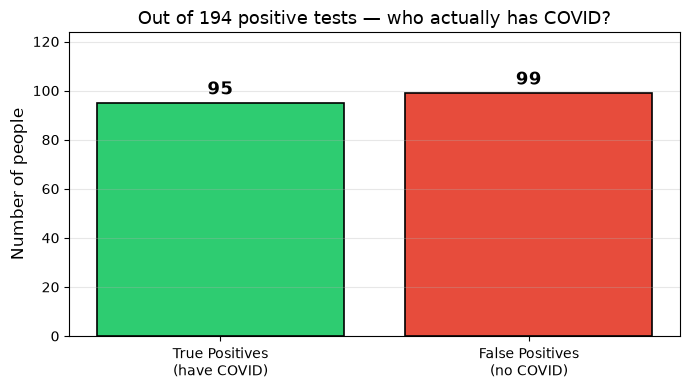

The 99 false positives nearly equal the 95 true positives.
That's why a positive test only means ~49% chance of COVID.


In [42]:
# Visualise: where do the positive tests come from?
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['True Positives\n(have COVID)', 'False Positives\n(no COVID)'],
              [true_positives, false_positives],
              color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.2)
ax.bar_label(bars, fontsize=13, fontweight='bold', padding=3)
ax.set_ylabel('Number of people', fontsize=12)
ax.set_title(f'Out of {total_positives} positive tests — who actually has COVID?',
             fontsize=13)
ax.set_ylim(0, max(true_positives, false_positives) * 1.25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The {false_positives} false positives nearly equal the {true_positives} true positives.")
print("That's why a positive test only means ~49% chance of COVID.")

The 99 false positives from the 9,900 healthy people almost equal the 95 true positives from the 100 sick people. That's the **base-rate trap**: when the condition is rare, false positives dominate.

### Questions

**B1.** In your own words, why is P(COVID | positive) so much lower than 95%? What role does the base rate play?

_Your answer here._

If we already know if the pathient already got covid, then is exactly 95%. However, we have to count the number that false alarm, and that is 99% *1%, which it enlarge the total number that got positive, making it less accurate then it seems. The larger the base case gets, the higher accurate for positive test gets, but still less than  95% accurates. 

**B2.** What would happen if the base rate were 10% instead of 1%? Compute it below.

In [45]:
# --- YOUR CODE HERE ---

base_rate_10 = 0.10

# Compute P(positive) with the new base rate
p_positive_10 = sensitivity*base_rate_10+ false_positive_rate*(1-base_rate_10)  # Replace

# Compute P(COVID | positive) with the new base rate
p_covid_given_pos_10 = sensitivity*base_rate_10/p_positive_10  # Replace

# --- END YOUR CODE ---

print(f"With 10% base rate:")
print(f"  P(COVID | positive) = {p_covid_given_pos_10:.4f} "
      f"({p_covid_given_pos_10*100:.1f}%)")
print(f"\nWith 1% base rate:")
print(f"  P(COVID | positive) = {p_covid_given_positive:.4f} "
      f"({p_covid_given_positive*100:.1f}%)")

With 10% base rate:
  P(COVID | positive) = 0.9135 (91.3%)

With 1% base rate:
  P(COVID | positive) = 0.4897 (49.0%)


**B3.** How does the base rate affect the reliability of a positive test? What does this mean for AI systems that screen for rare conditions (rare diseases, rare crimes, rare fraud)?

_Your answer here._

it needs high ratio of base rate, to get closer to the testing rate(positive rate), as if we want to apply this to a rare case, it will greatly become a false alarm.

---

## Part C: Bridge to Naive Bayes (preview of Week 7)

In Part A, you computed the effect of **one** word at a time. But real emails contain many words.

**Question:** Suppose a new email contains *both* "free" and "winner". How would you combine the evidence from both words to compute $P(\text{spam} | \text{"free", "winner"})$?

You don't need to compute it; just think about the approach.

<details>
<summary><b>Hint:</b> What if we assumed the words are independent?</summary>

If we assume that "free" and "winner" appear independently (given the class), then:

$$P(\text{"free", "winner"} | \text{spam}) = P(\text{"free"} | \text{spam}) \times P(\text{"winner"} | \text{spam})$$

This is the **naive** assumption in Naive Bayes ("naive" because words aren't really independent: "free" and "winner" tend to appear together in spam). But it works surprisingly well in practice.

Next week (P7), you'll implement this idea as a full classifier.
</details>

_Your answer here._

we will get each of the posibility, and if we consider it to be independent, then we can directly multiplies it. 

---

## Summary

| Concept | What it means |
|---|---|
| **Prior** $P(A)$ | What you believed before seeing evidence |
| **Likelihood** $P(B|A)$ | How likely the evidence is, given the hypothesis |
| **Evidence** $P(B)$ | How likely the evidence is overall |
| **Posterior** $P(A|B)$ | What you believe *after* seeing evidence (Bayes' rule) |

$$P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}$$

> **Lecture notation:** In the lecture slides, you'll see $P(H|D)$ where H = hypothesis and D = data. In this notebook, H = spam (or COVID) and D = "free" (or positive test). The formula is the same.

You'll use this exact formula in **P7** to build a Naive Bayes spam classifier.

---

## Part D: Reflection — "What goes wrong when we deploy probabilistic AI in high-stakes domains?" (P6.2)

Write a short reflective response (150–250 words) to the question:

> *"What goes wrong when we deploy probabilistic AI in high-stakes domains?"*

Think about the base-rate trap. A 95%-accurate test sounds reliable, but when the base rate is low, most positive results are false positives. Now imagine an AI system making bail decisions, cancer diagnoses, or threat assessments with similar base-rate blindness.

**Write your response in the cell below — it stays in this notebook.** You do not upload it as a separate file.

**P6.2 reflection — your response (150–250 words):**

*(Write your reflection here. Double-click this cell to edit. It stays in the notebook — do not upload it separately.)*

As we learn about this section, we can reach to a conclusion that it is not useful in a rare situation, which high stakes domains are just very minor part of lifes. As we get more data, for example: lung cancer data, we could make a more accurate decision. I believe that we could deply ai in medical diagnoses, because our medical system is very mature and we already collect a lot of decades of data, which i believe is enough for us to use for training an ai to diagnose. However, it will be a lot complicated because it have numourous reasons to cause a disease. According to WHO, 13% of death is becasue heart disease, and that have enough ratio for us to use this to diaganose it. 

---

## Submission checklist

- [x ] P6.1: Hand-computation of Bayes' rule on YOUR personalised scenario (photographed)
- [x ] P6.1: Articulation cell filled in (`answers` dict + `explanation`)
- [x ] Part A: Spam-detector probabilities computed (Steps 1–7) and Part A reflection answered
- [x ] Part B: Base-rate trap computed, with questions B1–B3 answered
- [x ] P6.2: Reflection on "What goes wrong when we deploy probabilistic AI in high-stakes domains?" (150–250 words, written in Part D of this notebook)
- [x ] Milestone discussion booked with tutor

**Uploading to OnTrack.** Submit **two things**: (1) this completed notebook, and (2) a **single** photo or PDF of your hand computation (P6.1). Your P6.2 reflection stays *inside this notebook* — OnTrack allows only one extra file besides the notebook, and that file is your hand computation.